
# Problem Statement

We are tasked with **Portfolio Optimization** for three stocks (A, B, C) using the **Mean Absolute Deviation (MAD)**
as a risk measure under a **Distributionally Robust Optimization (DRO)** framework.

Given:
- **Historical returns**: $ R \in \mathbb{R}^{3 \times 100}$, where $ R_{i,t} $ is the return of stock $i$ at time $t$
- **Risk tolerance**: $ \gamma = 0.015 $
- **Ambiguity set radius**: $ \epsilon = 0.05 $

We want to maximize expected return subject to a MAD constraint under the worst-case distribution.



# Step 1: Estimation of Expected Returns

The expected return for stock $ i $ is calculated as:

$
\hat{\mu}_i = \frac{1}{100} \sum_{t=1}^{100} R_{i,t}
$

This produces the **expected return vector**:

$
\hat{\mu} = \begin{bmatrix} \hat{\mu}_A \\ \hat{\mu}_B \\ \hat{\mu}_C \end{bmatrix}
$


In [38]:
import yfinance as yf
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np

tickers = ["NVDA", "MSFT", "JNJ"]
data = yf.download(tickers=tickers, start="2025-03-17", end="2025-08-09", auto_adjust=True)
close_prices = data["Close"] #Last 100 days adjusted close data
tickers = close_prices.columns.tolist() # rematch the order of the tickers
daily_returns = close_prices.pct_change().dropna()
daily_returns.to_csv("daily_returns.csv")
mu = daily_returns.mean().values
print(f"Expected returns (mu): {[f"{i * 100:.4f}%" for i in mu]}")
daily_returns.head()

[*********************100%***********************]  3 of 3 completed

Expected returns (mu): ['0.0824%', '0.3125%', '0.4732%']


Ticker,JNJ,MSFT,NVDA
Date,,,
2025-03-18,0.008659,-0.013327,-0.034301
2025-03-19,-0.007671,0.011212,0.018106
2025-03-20,0.000184,-0.002527,0.008594
2025-03-21,0.003742,0.011426,-0.007002
2025-03-24,-0.002078,0.004652,0.031521


The figure below shows the **daily returns** for each stock:

$$
r_{i,t} = \frac{P_{i,t} - P_{i,t-1}}{P_{i,t-1}}
$$

where $r_{i,t}$ is the daily return of stock $i$ on day $t$ and $P_{i,t}$ is its closing price.
Plotting these values over time allows us to visually compare volatility and trends across the selected stocks (NVDA, MSFT, JNJ).


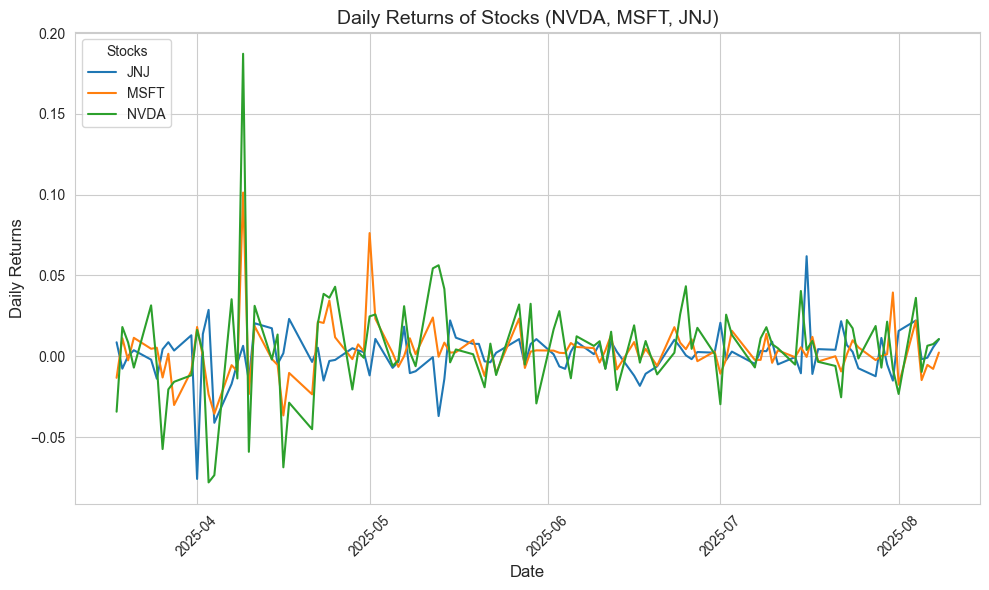

In [39]:
# Plot daily returns for each stock
plt.figure(figsize=(10, 6))

for ticker in tickers:
    plt.plot(daily_returns.index, daily_returns[ticker], label=ticker)

plt.title("Daily Returns of Stocks (NVDA, MSFT, JNJ)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Returns", fontsize=12)
plt.legend(title="Stocks", loc="upper left")
plt.grid(True)
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

The histogram below shows the **distribution of daily returns** for each stock.

By plotting the frequency of these returns, we can observe differences in volatility and skewness across the three assets (NVDA, MSFT, JNJ).

**Observations:**
- All three distributions are centered close to $0$, indicating no large bias toward gains or losses in the short term.
- NVDA shows a wider spread and heavier tails, suggesting higher volatility.
- MSFT and JNJ have narrower distributions, implying lower volatility.
- Extreme positive and negative returns are rare but more pronounced for NVDA.


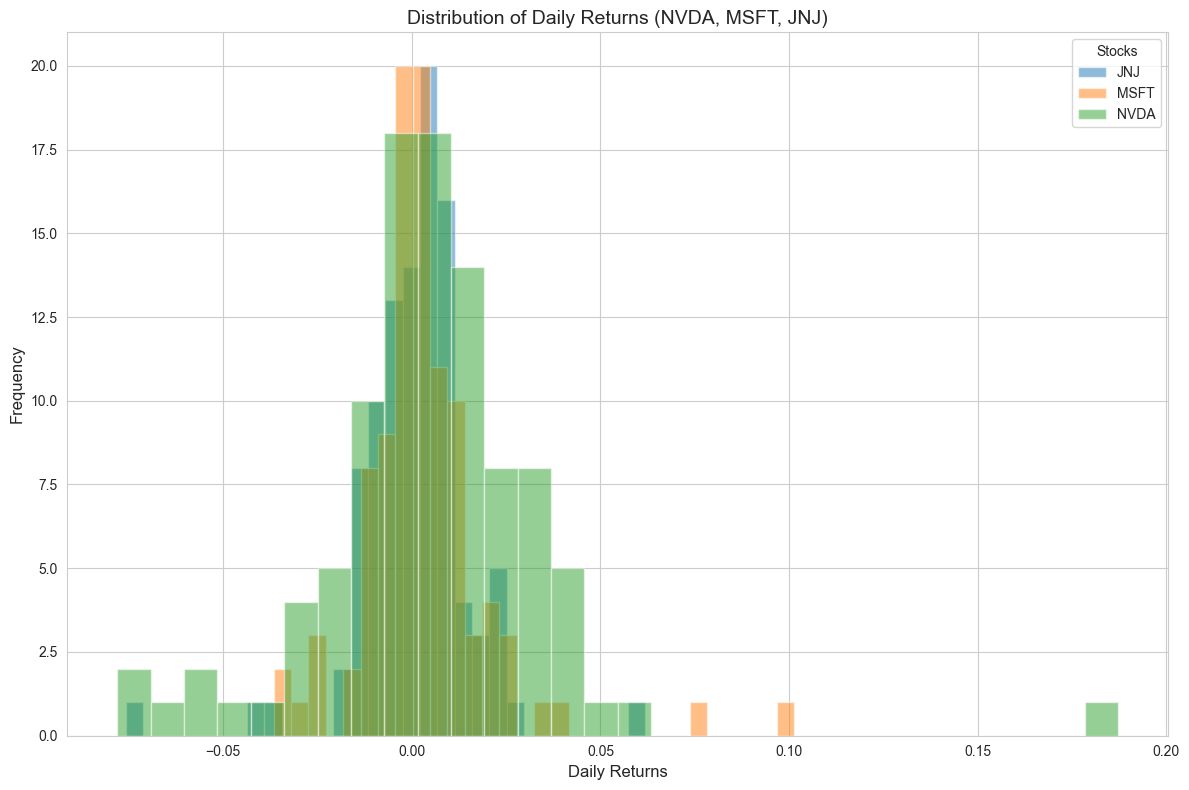

In [49]:
# Plot the distribution of daily returns for each stock
plt.figure(figsize=(12, 8))

for ticker in tickers:
    plt.hist(daily_returns[ticker], bins=30, alpha=0.5, label=ticker)

plt.title("Distribution of Daily Returns (NVDA, MSFT, JNJ)", fontsize=14)
plt.xlabel("Daily Returns", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(title="Stocks")
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

The plot below shows the **cumulative returns** for each stock, computed as:

$$
CR_{i,t} = \prod_{\tau=1}^t (1 + r_{i,\tau}) - 1
$$

where $CR_{i,t}$ is the cumulative return of stock $i$ up to day $t$ and $r_{i,\tau}$ is the daily return.

**Observations:**
- NVDA experienced the highest growth, ending with over $50\%$ cumulative return.
- MSFT also showed strong performance, finishing around $35\%$ cumulative return.
- JNJ’s performance remained relatively flat, indicating lower volatility but also limited upside.
- Both NVDA and MSFT show periods of drawdown followed by significant recoveries.


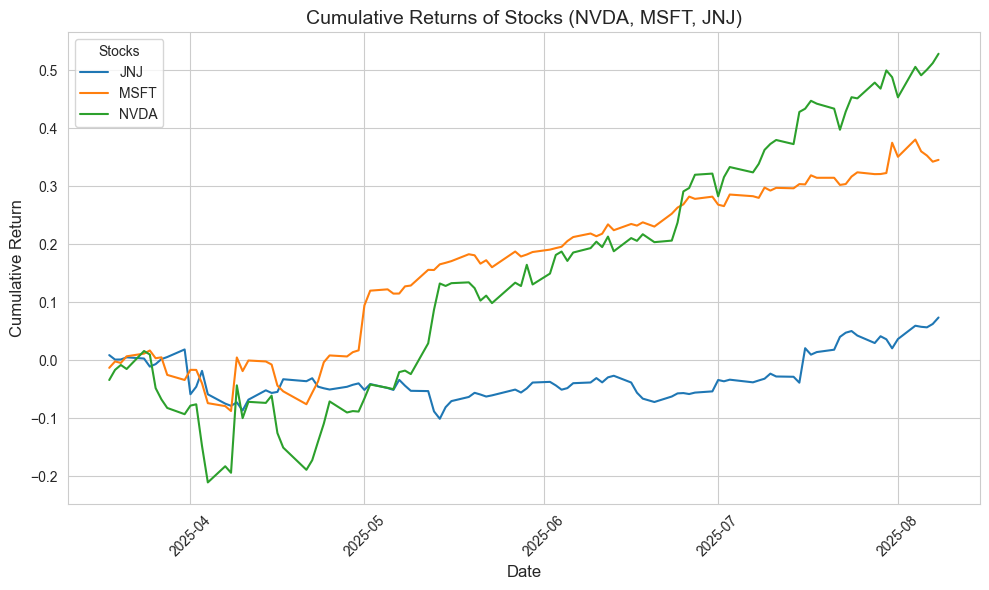

In [41]:
# Calculate cumulative returns for each stock
cumulative_returns = (1 + daily_returns).cumprod() - 1

# Plot cumulative returns for each stock
plt.figure(figsize=(10, 6))
for ticker in tickers:
    plt.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker)

plt.title("Cumulative Returns of Stocks (NVDA, MSFT, JNJ)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Cumulative Return", fontsize=12)
plt.legend(title="Stocks", loc="upper left")
plt.grid(True)
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()


# Step 2: Definition of Portfolio MAD

The **Mean Absolute Deviation** for a portfolio with weights $ w $ is given by:

$
MAD(w) = \frac{1}{100} \sum_{t=1}^{100} \left| \sum_{i=1}^3 w_i ( R_{i,t} - \hat{\mu}_i ) \right|
$

This measures the average absolute deviation of portfolio returns from their mean.



# Step 3: DRO Optimization Problem

We solve the following optimization:

$
\max_{w} \quad \hat{\mu}^\top w - \epsilon \cdot MAD(w)
$

Subject to:
$
\begin{aligned}
MAD(w) &\leq \gamma \\
\sum_{i=1}^3 w_i &= 1 \\
w_i &\geq 0, \quad i = 1,2,3
\end{aligned}
$


In [42]:
data = pd.read_csv("daily_returns.csv", index_col='Date', parse_dates=True)

w = cp.Variable(3)
abs_deviation = cp.abs(cp.multiply(w, data.values - mu))
MAD = cp.sum(cp.sum(abs_deviation, axis=1)) / data.shape[0]

gamma = 0.015
epsilon = 0.05
objective = cp.Maximize(cp.sum(cp.multiply(w, mu)) - epsilon * MAD)
constraints = [cp.sum(w) == 1, w >= 0, MAD <= gamma]

problem = cp.Problem(objective, constraints)
problem.solve()

optimal_weights = w.value
print(f"excpected daily portfolio return: {(mu @ optimal_weights) * 100:.3f}%")
print(f"portfilio MAD: {MAD.value:.5f}")
print(f"optimal weights: {optimal_weights}")

excpected daily portfolio return: 0.380%
portfilio MAD: 0.01500
optimal weights: [3.08571165e-10 5.77847989e-01 4.22152011e-01]


C:\Users\I745460\PycharmProjects\Financial_DS_focus_sessions\.venv\Lib\site-packages\cvxpy\reductions\solvers\solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(



# Step 4: Results Interpretation

Once we obtain the optimal weights $ w^* $, we compute:
- **Expected portfolio return**: $ \hat{\mu}^\top w^* $
- **Portfolio MAD**: $ MAD(w^*) $
(see above)

These metrics tell us the risk-return profile under the DRO framework.

The chart below shows the **optimal portfolio weights** obtained from solving the optimization problem:

$$
\max_{w} \quad \hat{\mu}^\top w - \epsilon \cdot MAD(w)
$$

subject to:
$$
MAD(w) \leq \gamma, \quad \sum_{i=1}^3 w_i = 1, \quad w_i \geq 0
$$

**Observations:**
- MSFT has the largest allocation ($57.8\%$), indicating a favorable risk-return profile.
- NVDA holds $42.2\%$ of the portfolio, for stability and diversification. It's lower contribution to the portfolio suggests that its volatility outweighs its expected return under the MAD and DRO constraints.
- JNJ receives $0\%$ allocation as it gets outperformed by the other two stocks in terms of risk-adjusted returns.



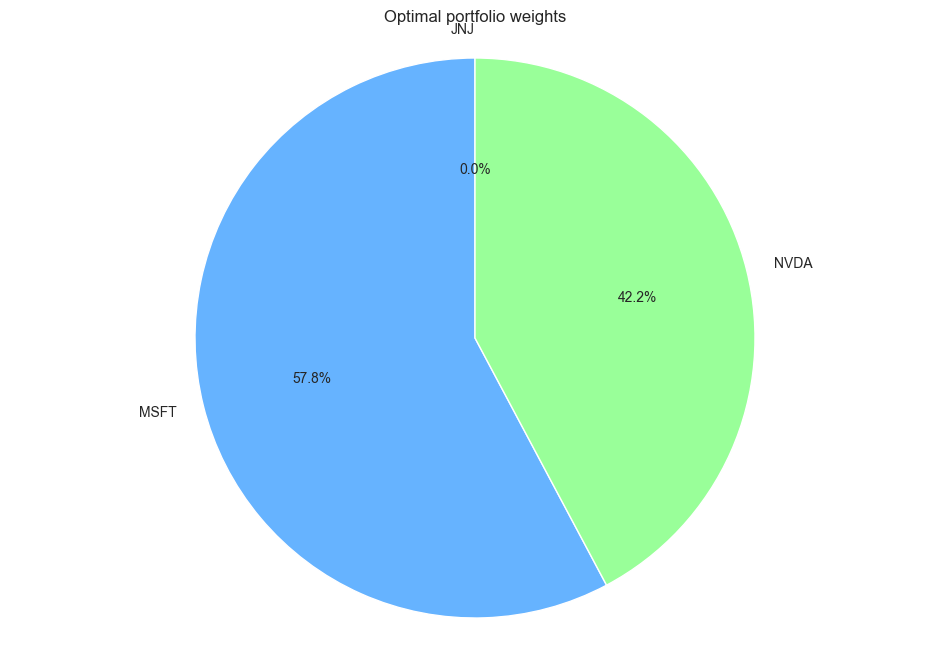

In [43]:
plt.figure(figsize=(12, 8))
plt.pie(optimal_weights, labels=tickers, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title("Optimal portfolio weights")
plt.axis('equal')
plt.show()

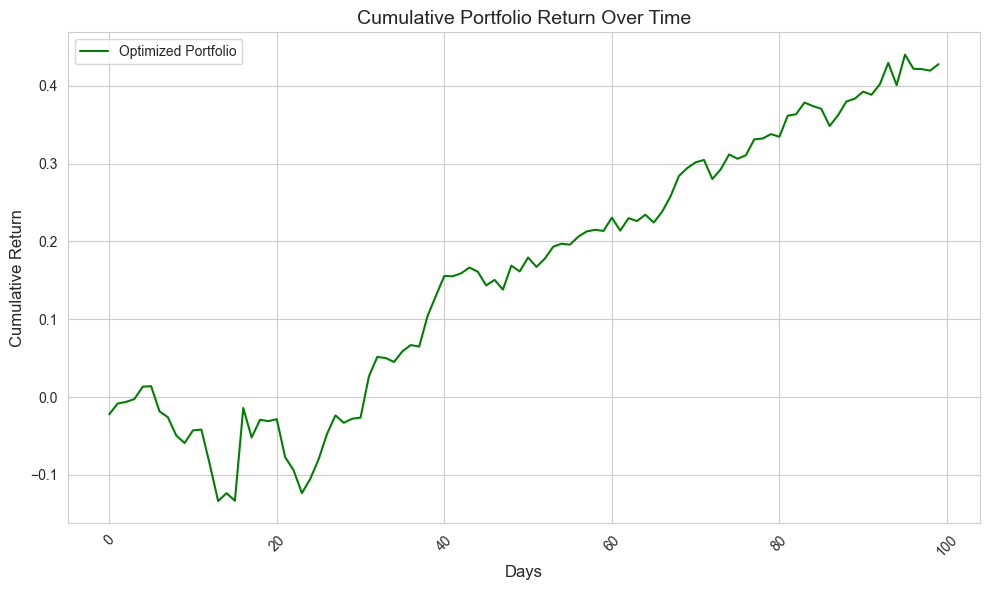

Optimal Portfolio Expected Daily Return: 0.380%
Optimal Portfolio Volatility (Risk): 2.214%


In [47]:
cov_matrix = daily_returns.cov().values
# 1. Expected return and volatility (risk) of the optimal portfolio
expected_return = np.sum(optimal_weights * mu)
portfolio_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix, optimal_weights)))

# 2. Portfolio performance over time
portfolio_returns = np.dot(daily_returns.values, optimal_weights)
cumulative_portfolio_returns = (1 + portfolio_returns).cumprod() - 1

plt.figure(figsize=(10, 6))
plt.plot(cumulative_portfolio_returns, label="Optimized Portfolio", color="green")
plt.title("Cumulative Portfolio Return Over Time", fontsize=14)
plt.xlabel("Days", fontsize=12)
plt.ylabel("Cumulative Return", fontsize=12)
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Output the results for the user
print(f"Optimal Portfolio Expected Daily Return: {expected_return * 100:.3f}%")
print(f"Optimal Portfolio Volatility (Risk): {portfolio_volatility * 100:.3f}%")